In [14]:
from Scherrer_LmFit import *
import matplotlib.pyplot as plt
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox

root = tk.Tk()
root.withdraw()
root.wm_attributes('-topmost', 1)  # Ensure dialog is on top
npz_file = filedialog.askopenfilename(title="Select GIWAXS .npz file", filetypes=[("NPZ files", "*.npz")])

In [10]:




cif_file = r'CH3NH3PbI3_cubic.cif'
a_lattice = get_lattice_from_cif(cif_file)
print("Lattice Parameter", f"Read a = {a_lattice:.4f} Å from CIF.")


data = np.load(npz_file)
q = data['q']
time = data['time']
intensity = data['intensity']

hkl_peaks = generate_cubic_hkl_q(a_lattice)
middle_idx = len(time) // 2
I_middle = intensity[middle_idx, :]
peak_indices, _ = find_peaks(I_middle, height=np.max(I_middle)*0.1, distance=5)
q_peaks = q[peak_indices]
matched_peaks = match_peaks_to_hkl(q_peaks, hkl_peaks)

all_results = {}
prev_fit_params = {}
output_dir = os.path.splitext(npz_file)[0] + '_fit_plots'


Lattice Parameter Read a = 6.2288 Å from CIF.


c:\Users\Aj\Documents\GitHub\MultiModalAnalysis\Scherrer_analysis\Scherrer_LmFit.py:33: FutureWarning: get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
  structure = parser.get_structures()[0]


In [11]:
print("Detected peaks (q):", q_peaks)

Detected peaks (q): [1.02803946 1.42646869 1.73395212 1.99379728 2.15403512 2.22332716
 2.43553404 2.80797876 2.97687811 3.44026863 4.11586603 4.57059505]


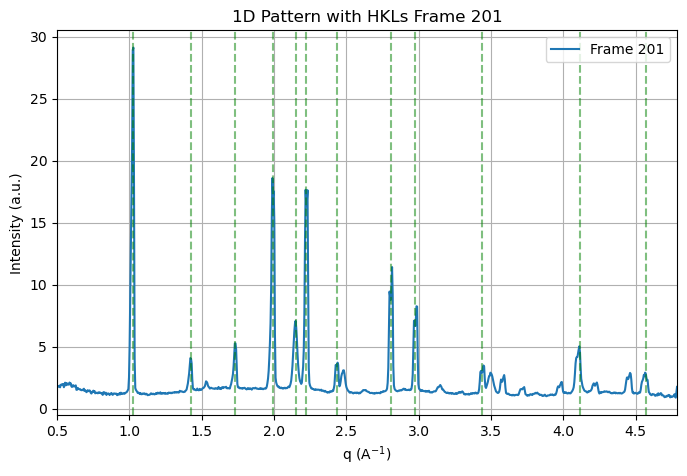

In [13]:
i = 200

# process_frame(i, q, time, intensity[i, :], matched_peaks, prev_fit_params, output_dir)
frame_idx = i + 1
I = intensity[i, :]
vline_subfolder = os.path.join(output_dir, f'VlinePlots')
os.makedirs(vline_subfolder, exist_ok=True)
plt.figure(figsize=(8,5))
plt.plot(q, I, label=f'Frame {frame_idx}')
# for (h, k, l, q_target) in matched_peaks:
#     plt.axvline(q_target, color='r', linestyle='--', alpha=0.5)
#     plt.text(q_target, np.max(I)*0.9, f'({h}{k}{l})', rotation=90, fontsize=8, ha='center')
for q_peak in q_peaks:
    plt.axvline(q_peak, color='g', linestyle='--', alpha=0.5)
plt.xlabel('q (A$^{-1}$)')
plt.xlim(.5, max(q))
plt.ylabel('Intensity (a.u.)')
plt.title(f'1D Pattern with HKLs Frame {frame_idx}')
plt.legend()
plt.grid()
plt.show()